In [1]:
import os
import pathlib

import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import pingouin as pg
import seaborn as sns


import STX3KO_analyses as stx
u = stx.utilities

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice

plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'

%matplotlib inline

%load_ext autoreload
%autoreload 2


In [ ]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS5_naive_bayes')
figdir.mkdir(exist_ok=True, parents=True)


In [103]:
rows = []

days = np.arange(6)
mouse = ctrl_mice[0]
for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice,ko_mice)):
    for mouse in mice:
        sess = u.single_mouse_concat_sessions(mouse, days)
        for ttype in ('fam', 'nov'):
            for train_day in days:
                for test_day in days:
                    
                    train_mask = sess.trial_info['sess_num']==train_day
                    test_mask = sess.trial_info['sess_num']==test_day

                    if ttype == 'fam':
                        ttype_mask = sess.trial_info['LR']!=sess.novel_arm
                    else:
                        ttype_mask = sess.trial_info["LR"]==sess.novel_arm

                    train_mat = np.nanmean(sess.trial_matrices['F_dff'][train_mask*ttype_mask,:,:],axis=0, keepdims=False)
                    test_mat = sess.trial_matrices['F_dff'][test_mask*ttype_mask,:,:]

                    train_mat -= np.nanmin(train_mat,axis=-1,keepdims=True)
                    train_mat[np.isnan(train_mat)]=0
                    train_mat += 1E-3

                    test_mat -= np.nanmin(test_mat,axis=-1,keepdims=True)
                    test_mat[np.isnan(test_mat)]=0
                    test_mat += 1E-3


                    post = []
                    for trial in range(test_mat.shape[0]):
                        post.append(stx.naive_bayes.test(test_mat[trial,:,:], train_mat, poisson=True))
                    post = np.array(post)
                    err = stx.naive_bayes.abs_err(post).mean()
                    # print(err)

                    rows.append({
                        'cond': cond,
                        'mouse': mouse,
                        'ttype': ttype,
                        'train_day': train_day,
                        'test_day': test_day,
                        'err': err,
                    })

df = pd.DataFrame(rows)



29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


/tmp/ipykernel_425990/3738877694.py:27: RuntimeWarning: All-NaN slice encountered
  test_mat -= np.nanmin(test_mat,axis=-1,keepdims=True)


29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


/tmp/ipykernel_425990/3738877694.py:27: RuntimeWarning: All-NaN slice encountered
  test_mat -= np.nanmin(test_mat,axis=-1,keepdims=True)


29_11_2020 YMaze_LNovel
30_11_2020 YMaze_LNovel
01_12_2020 YMaze_LNovel
02_12_2020 YMaze_LNovel
03_12_2020 YMaze_LNovel
04_12_2020 YMaze_LNovel


...

/tmp/ipykernel_425990/3738877694.py:27: RuntimeWarning: All-NaN slice encountered
  test_mat -= np.nanmin(test_mat,axis=-1,keepdims=True)


18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
22_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


/tmp/ipykernel_425990/3738877694.py:27: RuntimeWarning: All-NaN slice encountered
  test_mat -= np.nanmin(test_mat,axis=-1,keepdims=True)


18_10_2021 YMaze_LNovel
19_10_2021 YMaze_LNovel
20_10_2021 YMaze_LNovel
21_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel
23_10_2021 YMaze_LNovel


/tmp/ipykernel_425990/3738877694.py:27: RuntimeWarning: All-NaN slice encountered
  test_mat -= np.nanmin(test_mat,axis=-1,keepdims=True)


In [104]:
df.to_pickle('/home/mplitt/shuffle_pkls/dense_naive_bayes_across_days_results.pkl')

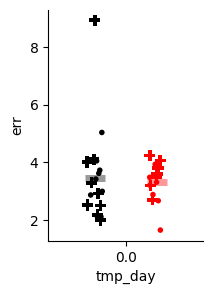

In [110]:
df['tmp_day'] = 0
tmp_df = df.groupby(['cond', 'mouse', 'ttype']).mean().reset_index()
fig,ax = plt.subplots(figsize=[2,3], sharey = True)
for i, ttype in enumerate(('fam','nov')):
    if ttype == 'nov':
        marker = 'P'
        s = 8
    else:
        marker = '.'
        s = 8
    sns.stripplot(data=tmp_df.loc[tmp_df['ttype']==ttype,:],
                x='tmp_day',
                y='err',
                hue='cond', 
                hue_order=('ctrl', 'ko'), 
                palette=['black', 'red'],
                dodge=True,
                ax=ax, marker = marker, s=s,
                legend=False)
    


sns.pointplot(data=tmp_df,
            x='tmp_day',
            y='err',
            errorbar=None,
            hue='cond',
            hue_order = ['ctrl', 'ko'],
            dodge = .4,
            palette = ['black', 'red'],
            ax=ax,
            linestyles="none",
            marker="_", markersize=15, markeredgewidth=5, legend=False, alpha=.4,
            )
    


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



fig.savefig(figdir / f"naive_bayes_across_day_summary.pdf", bbox_inches='tight')

In [137]:
import itertools
decode_errs = {}

for cond, mice in zip(('ctrl', 'ko'), (ctrl_mice, ko_mice)):
    decode_errs[cond] = {}
    for ttype in ('fam', 'nov'):
        decode_errs[cond][ttype] = []
        for mouse in mice:
            err = np.zeros((6,6))*np.nan
            for train_day, test_day in itertools.product(days, days):
                mask = (df['mouse']==mouse) * (df['train_day']==train_day) * (df['test_day']==test_day) 
                mask = mask * (df['ttype']==ttype)
                if train_day != test_day:
                    err[train_day,test_day] = df.loc[mask,'err']

            decode_errs[cond][ttype].append(err)
        decode_errs[cond][ttype] = np.array(decode_errs[cond][ttype])

/tmp/ipykernel_425990/757123512.py:14: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  err[train_day,test_day] = df.loc[mask,'err']


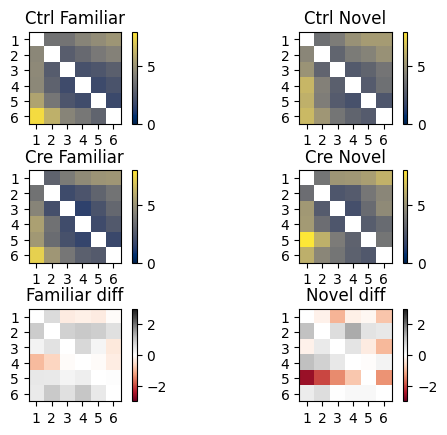

In [140]:
fig, ax = plt.subplots(3,2)
h = ax[0,0].imshow(decode_errs['ctrl']['fam'].mean(axis=0),cmap='cividis', vmin=0, vmax=8)
plt.colorbar(h)
ax[0,0].set_title('Ctrl Familiar')

h = ax[0,1].imshow(decode_errs['ctrl']['nov'].mean(axis=0),cmap='cividis', vmin=0, vmax=8)
plt.colorbar(h)
ax[0,1].set_title('Ctrl Novel')

h = ax[1,0].imshow(decode_errs['ko']['fam'].mean(axis=0),cmap='cividis', vmin=0, vmax=8)
plt.colorbar(h)
ax[1,0].set_title('Cre Familiar')

h = ax[1,1].imshow(decode_errs['ko']['nov'].mean(axis=0),cmap='cividis', vmin=0, vmax=8)
plt.colorbar(h)
ax[1,1].set_title('Cre Novel')

diff = decode_errs['ctrl']['fam'].mean(axis=0) - decode_errs['ko']['fam'].mean(axis=0)
h = ax[2,0].imshow(diff,cmap='RdGy', vmin=-3, vmax=3)
plt.colorbar(h)
ax[2,0].set_title('Familiar diff')

diff = decode_errs['ctrl']['nov'].mean(axis=0) - decode_errs['ko']['nov'].mean(axis=0)
h = ax[2,1].imshow(diff,cmap='RdGy', vmin=-3, vmax=3)
plt.colorbar(h)
ax[2,1].set_title('Novel diff')


plt.subplots_adjust(hspace=.5)

for a in ax.flatten():
    a.set_xticks(np.arange(6), labels=np.arange(1,7))
    a.set_yticks(np.arange(6), labels=np.arange(1,7))

fig.savefig(figdir / "naive_bayes_across_day.pdf")